# Machine Learning Introduction
## Проект: Предсказание арендной цены квартир (Two Sigma Connect)

## 1. Введение (Intro)

**1.1 Пять примеров применения ML в жизни:**

1. **Рекомендательные системы (Netflix, Spotify)** — ML анализирует историю просмотров/прослушиваний и предлагает релевантный контент. Преимущество: персонализация в масштабе миллионов пользователей, невозможная вручную.

2. **Медицинская диагностика по снимкам** — нейросети анализируют рентген/МРТ и выявляют патологии. Преимущество: скорость и точность обнаружения заболеваний на ранней стадии.

3. **Автопилот и беспилотные автомобили (Tesla, Waymo)** — ML обрабатывает данные с камер, лидаров и радаров для навигации. Преимущество: снижение количества ДТП, вызванных человеческим фактором.

4. **Фильтрация спама в email** — классификация писем на спам/не спам на основе текста и метаданных. Преимущество: экономия времени, защита от фишинга.

5. **Кредитный скоринг** — оценка вероятности возврата кредита на основе финансовой истории клиента. Преимущество: быстрое и объективное решение о выдаче кредита.

**1.2 Классификация задач из таблицы и примеров:**

**Из таблицы README:**
1. Predict house price — **Supervised, Regression**
2. Predict loan return — **Supervised, Binary Classification**
3. Predict medicine timing — **Supervised, Regression/Classification**
4. Choose medicine — **Supervised, Multiclass Classification**
5. Choose client segment for promo — **Supervised, Classification** (или Unsupervised Clustering)
6. Recognition of defects — **Supervised, Binary Classification**
7. Product placement — **Supervised, Regression** (или Reinforcement Learning)
8. Search sites — **Supervised, Ranking/Regression**
9. Customer segmentation — **Unsupervised, Clustering**
10. Anomaly detection — **Unsupervised / Semi-supervised, Anomaly Detection**

**Мои 5 примеров:**
1. Рекомендательные системы — **Unsupervised (Clustering/Association)** + Supervised
2. Медицинская диагностика — **Supervised, Binary/Multiclass Classification**
3. Автопилот — **Supervised, Multiclass Classification + Regression**
4. Фильтрация спама — **Supervised, Binary Classification**
5. Кредитный скоринг — **Supervised, Binary Classification / Regression**

**1.3 Разница между multiclass и multilabel:**

- **Multiclass (многоклассовая):** каждый объект принадлежит **ровно одному** классу из множества. Пример: распознавание цифр 0-9 — каждая цифра относится к одному классу.

- **Multilabel (многометочная):** каждый объект может принадлежать **нескольким классам одновременно**. Пример: тегирование фильма — фильм может быть одновременно «комедия», «романтика» и «драма».

**1.4 Является ли пример с ценами на жильё классификацией или регрессией?**

Пример с ценами на жильё — это **задача регрессии**, так как целевая переменная (цена) является непрерывной вещественной величиной.

**Можно ли свести регрессию к классификации?** Да, можно. Например, разбив цены на диапазоны (бины): «дешёвые» (< $100k), «средние» ($100k–$300k), «дорогие» (> $300k) — и предсказывать категорию вместо точной цены. Однако при этом теряется точность прогноза.

## 2. Введение в анализ данных

### 2.1 Импорт библиотек

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import statsmodels.api as sm
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, root_mean_squared_error


# === Настройки отображения ===
pd.set_option("display.max_columns", None)   # показывать все столбцы
sns.set_theme(style="whitegrid")             # единый стиль графиков
plt.style.use('seaborn-v0_8-whitegrid')      # единый стиль графиков

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


print("Все библиотеки успешно импортированы!")

Все библиотеки успешно импортированы!


### 2.2 Загрузка данных

In [72]:
df = pd.read_json("data/train.json")
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


### 2.3 Размер данных(кол-во строк и столбцов)

In [73]:
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов {df.shape[1]}")
print(f"Общий размер: {df.shape}")

Количество строк: 49352
Количество столбцов 15
Общий размер: (49352, 15)


### 2.4 Список столбцов и целевая переменная

In [74]:
# print('Столбцы датасета')
# df.columns
print("Столбцы датасета:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")
print("\nЦелевая переменная — price")


Столбцы датасета:
  1. bathrooms
  2. bedrooms
  3. building_id
  4. created
  5. description
  6. display_address
  7. features
  8. latitude
  9. listing_id
  10. longitude
  11. manager_id
  12. photos
  13. price
  14. street_address
  15. interest_level

Целевая переменная — price


### 2.5 Быстрый анализ данных

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [76]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [77]:
df.select_dtypes(include='number').corr()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


### Выводы по краткому анализу данных:
- df.info() показывает, что пропуски в данных отсутствуют, и какой тип значения имеет каждая фича
- df.describe() показывает количество значений, среднее зн, стд, мни/макс и квартили каждой числовой фичи
- df.select_dtypes(include='number').corr() показывает корреляцию между фичами. Наибольяная корреляция у фичей
bathrooms и bedrooms

### 2.6 Создание DataFrame с 4 столбцами

In [78]:
features = ['bathrooms', 'bedrooms', 'interest_level']
df_selected = df[features +  ['price']].copy()
df_selected = df_selected.reset_index(drop=True)
print(f"Новый размер: {df.shape}")
df_selected.head()

Новый размер: (49352, 15)


,bathrooms,bedrooms,interest_level,price
0,1.0,1,medium,2400
1,1.0,2,low,3800
2,1.0,2,medium,3495
3,1.5,3,medium,3000
4,1.0,0,low,2795


## 3. Статистический анализ данных

### 3.3 Анализ целевой переменной (price)

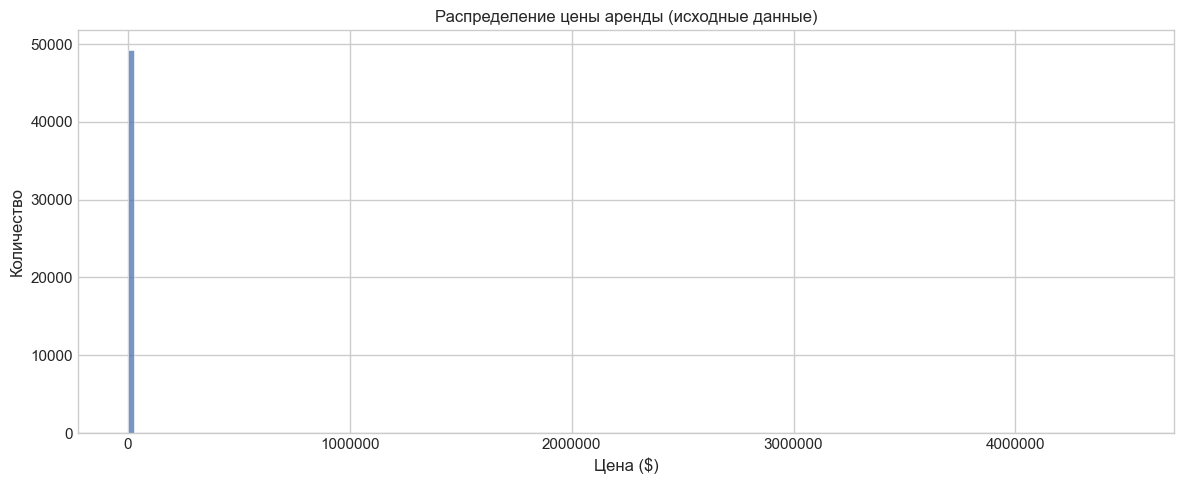

In [79]:
# 3.3.1 Гистограмма распределения цены
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(data=df_selected, x="price", bins=150, ax=ax)
ax.set_title("Распределение цены аренды (исходные данные)")
ax.set_xlabel("Цена ($)")
ax.set_ylabel("Количество")
ax.ticklabel_format(style="plain", axis="x")  # убрать научную запись (1e6) на оси X
plt.tight_layout()
plt.show()

Распределение сильно скошено вправо (right-skewed).
Из-за единичных экстремальных цен (макс. ~4.5 млн) вся основная масса данных сжата в один столбик слева — это наглядно показывает выбросы. Один-два объявления с ценой в 4.5 миллиона растягивают ось X до 1e6. В итоге все 49352 нормальные квартиры ужимаются в один столбик у нуля. Это и есть наглядная демонстрация выбросов


Главный признак правого скоса: среднее > медианы.
Метрика	Значение
Медиана (50%)	≈ 3 150
Среднее (mean)	≈ 3 830


Среднее — плохая «типичная» цена. Из-за скоса оно завышено и не отражает реальность. Для скошенных данных «типичное» значение лучше описывает медиана.
Это прямая подсказка к главе V: наивная модель на медиане (naive_median) скорее всего обыграет модель на среднем (naive_mean) — как раз из-за правого скоса.

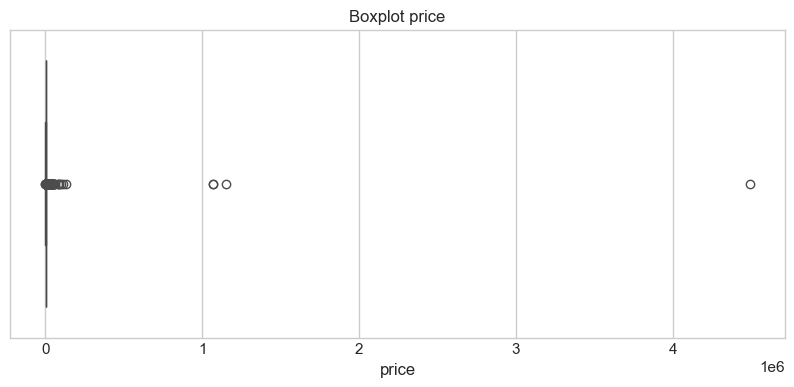

In [80]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_selected['price'])
plt.title('Boxplot price')
plt.show()


«Коробка» (основная масса данных) прижата к левому краю, а справа — куча отдельных точек. Это и есть выбросы. «Boxplot подтверждает наличие большого числа выбросов в верхней части — экстремально высокие цены».

Boxplot показывает наличие множества выбросов (точки выше усов).
Медиана значительно ниже среднего — признак right-skewed распределения.

In [81]:
# Удаление выбросов по 1-му и 99-му процентилям
lower = df_selected['price'].quantile(0.01)
upper = df_selected['price'].quantile(0.99)

print(f"Нижняя граница (1%): {lower}")
print(f"Верхняя граница (99%): {upper}")
print(f"Строк до очистки: {df_selected.shape[0]}")

df_selected = df_selected[(df_selected['price'] >= lower) & (df_selected['price'] <= upper)]

print(f"Строк после очистки: {df_selected.shape[0]}")

Нижняя граница (1%): 1475.0
Верхняя граница (99%): 13000.0
Строк до очистки: 49352
Строк после очистки: 48379


Считаем границы 1% самых дешёвых и 1% самых дорогих цен, затем оставляем только те строки, что попадают между ними — так «хвосты» с выбросами отсекаются, и распределение становится читаемым 

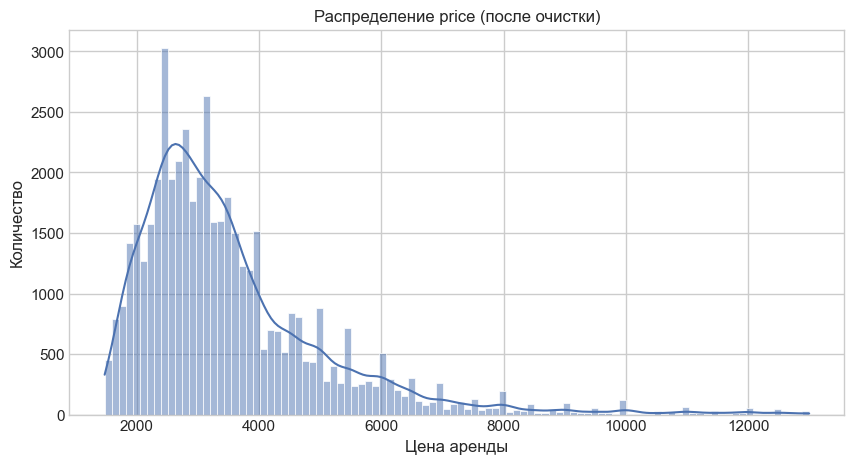

In [82]:
plt.figure(figsize=(10, 5))
sns.histplot(df_selected['price'], bins=100, kde=True)
plt.title('Распределение price (после очистки)')
plt.xlabel('Цена аренды')
plt.ylabel('Количество')
plt.show()

Теперь распределение читается — видна основная масса цен, форма близка к нормальной, но всё ещё с лёгким скосом вправо (типично для цен). После удаления выбросов распределение стало интерпретируемым, виден реальный диапазон цен аренды. Небольшая правосторонняя асимметрия сохраняется, что нормально для ценовых данных.

### 3.4 Анализ характеристик

Анализ характеристик:

Закодируйте эти значения. Например, можно заменить каждое значение на 0, 1 или 2.
Постройте гистограммы для признаков bathrooms, bedrooms. Есть ли выбросы?

In [83]:
# Какой тип у столбца interest_level?
print(f"Тип столбца 'interest_level': {df_selected['interest_level'].dtype}")

Тип столбца 'interest_level': object


In [84]:
# Выведите значения в этом столбце. Сколько записей содержит каждое значение?
print('Значения столбца interest_level и количество записей в стобце')
df_selected['interest_level'].value_counts()

Значения столбца interest_level и количество записей в стобце


interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

In [85]:
# Кодирование фичи 'interest_level'
interest_mapping = {'low': 0, 'medium': 1, 'high': 2}

df_selected['interest_level'] = df_selected['interest_level'].map(interest_mapping)

print(df_selected['interest_level'].value_counts())
df_selected.head()

interest_level
0    33697
1    11116
2     3566
Name: count, dtype: int64


,bathrooms,bedrooms,interest_level,price
0,1.0,1,1,2400
1,1.0,2,0,3800
2,1.0,2,1,3495
3,1.5,3,1,3000
4,1.0,0,0,2795


interest_level — упорядоченная категория (low < medium < high), поэтому применяем ordinal encoding через .map({'low':0,'medium':1,'high':2}). Теперь признак числовой и пригоден для корреляционного анализа и обучения модели.

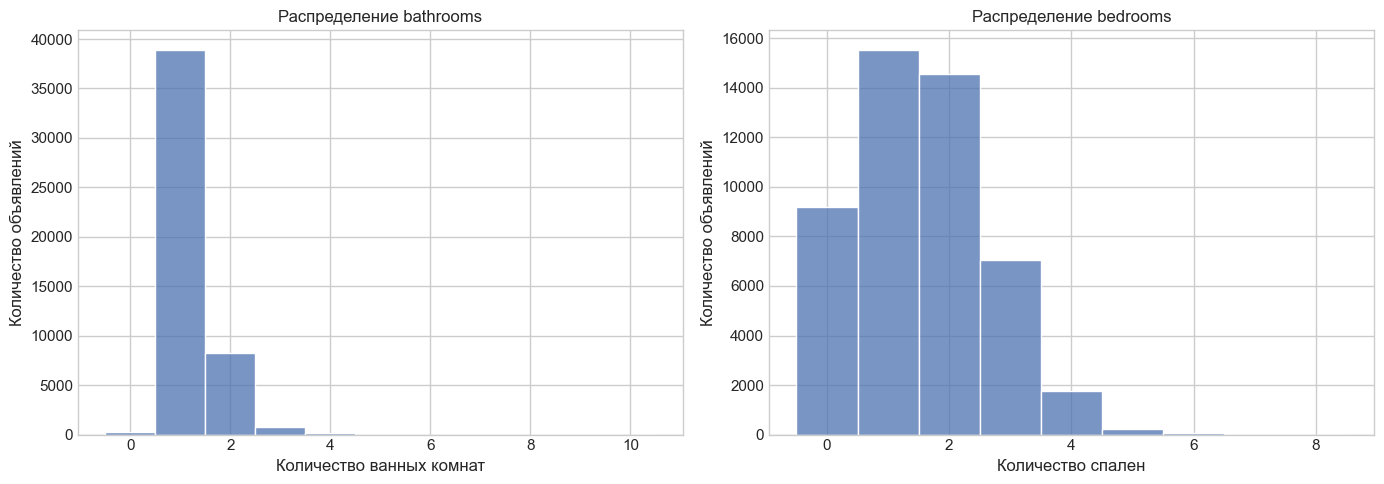

In [86]:
# Гистограммы признаков bathrooms и bedrooms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- bathrooms ---
sns.histplot(data=df_selected, x="bathrooms", ax=axes[0], discrete=True)
axes[0].set_title("Распределение bathrooms")
axes[0].set_xlabel("Количество ванных комнат")
axes[0].set_ylabel("Количество объявлений")

# --- bedrooms ---
sns.histplot(data=df_selected, x="bedrooms", ax=axes[1], discrete=True)
axes[1].set_title("Распределение bedrooms")
axes[1].set_xlabel("Количество спален")
axes[1].set_ylabel("Количество объявлений")

plt.tight_layout()
plt.show()

Оба признака дискретны и скошены вправо. У bathrooms подавляющее большинство — 1 ванная, значения ≥3 редки (выбросы). У bedrooms преобладают 0–2 спальни, значения ≥5 — выбросы. Это нормально для рынка аренды: большинство квартир небольшие, элитные — единичны.

### 3.5 Комплексный анализ

Комплексный анализ:
Постройте матрицу корреляции для понимания связи между признаками и целевой переменной. Постройте тепловую карту матрицы корреляции. Есть ли корреляция?

Постройте диаграмму рассеяния для визуализации корреляции между признаками и целевой переменной. Должно получиться 3 графика, где ось X — целевая переменная, ось Y — признак.

                bathrooms  bedrooms  interest_level     price
bathrooms        1.000000  0.517574       -0.063635  0.671943
bedrooms         0.517574  1.000000        0.050654  0.545948
interest_level  -0.063635  0.050654        1.000000 -0.200111
price            0.671943  0.545948       -0.200111  1.000000


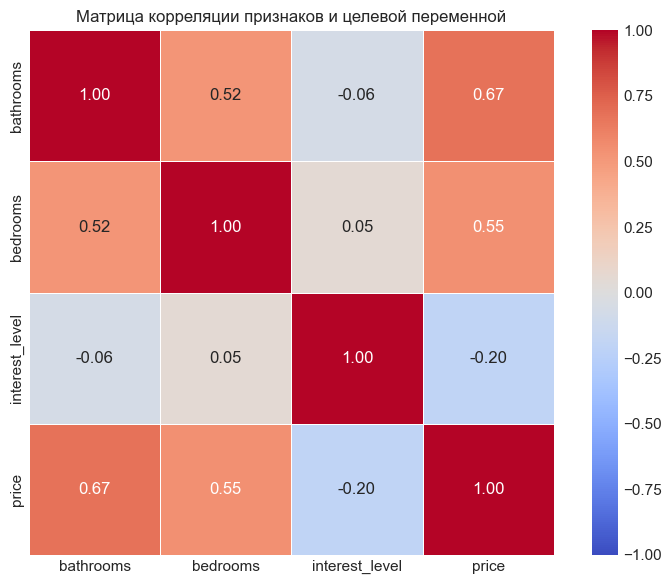

In [87]:
# Матрица корреляции и heatmap
corr_matrix = df_selected.corr()
print(corr_matrix)

# Тепловая карта
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,        # писать числа в клетках
    cmap="coolwarm",   # цветовая схема: синий (-) ↔ красный (+)
    fmt=".2f",         # округлять до 2 знаков
    vmin=-1, vmax=1,   # фиксируем шкалу от -1 до 1
    square=True,       # квадратные клетки
    linewidths=0.5     # тонкие линии между клетками
)
plt.title("Матрица корреляции признаков и целевой переменной")
plt.tight_layout()
plt.show()

bathrooms и bedrooms заметно коррелируют между собой что логично, в больших квартирах больше и спален, и ванных. Также хорошая корреляция с ценой

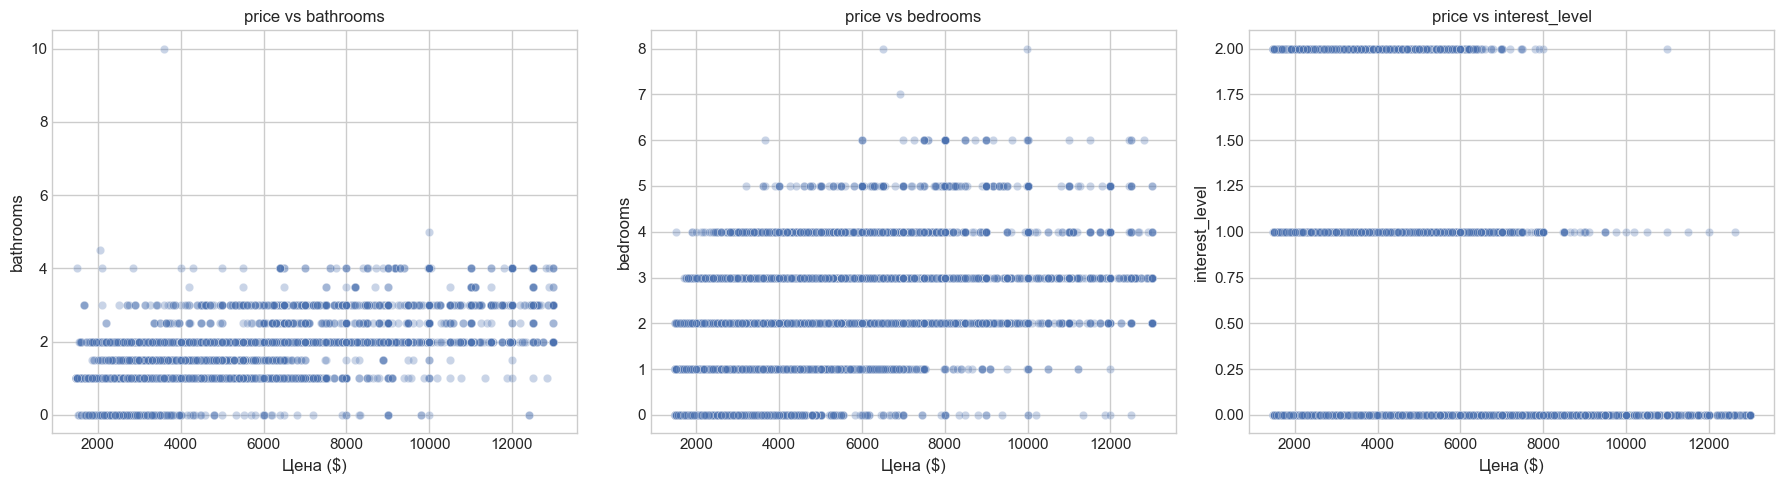

In [88]:
# Диаграммы рассеяния: X = price (целевая), Y = признак
features = ['bathrooms', 'bedrooms', 'interest_level']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(features):
    sns.scatterplot(data=df_selected, x="price", y=feature, ax=axes[i], alpha=0.3)
    axes[i].set_title(f"price vs {feature}")
    axes[i].set_xlabel("Цена ($)")
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()


Признаки дискретны, поэтому точки образуют горизонтальные полосы. Чёткой линейной зависимости "цена → признак" не сильно видно, но прослеживается тенденция: дорогие квартиры чаще имеют больше спален/ванных, а более дешевые варианты соответственно меньше ванных и спальных комнат. Уровень интересе сосредоточен к квартирам дешевого и среднего ценового сегмента от 1000 до 8000 цены.

## 4. Создание признаков

### 4.1 Создание квадратичных признаков

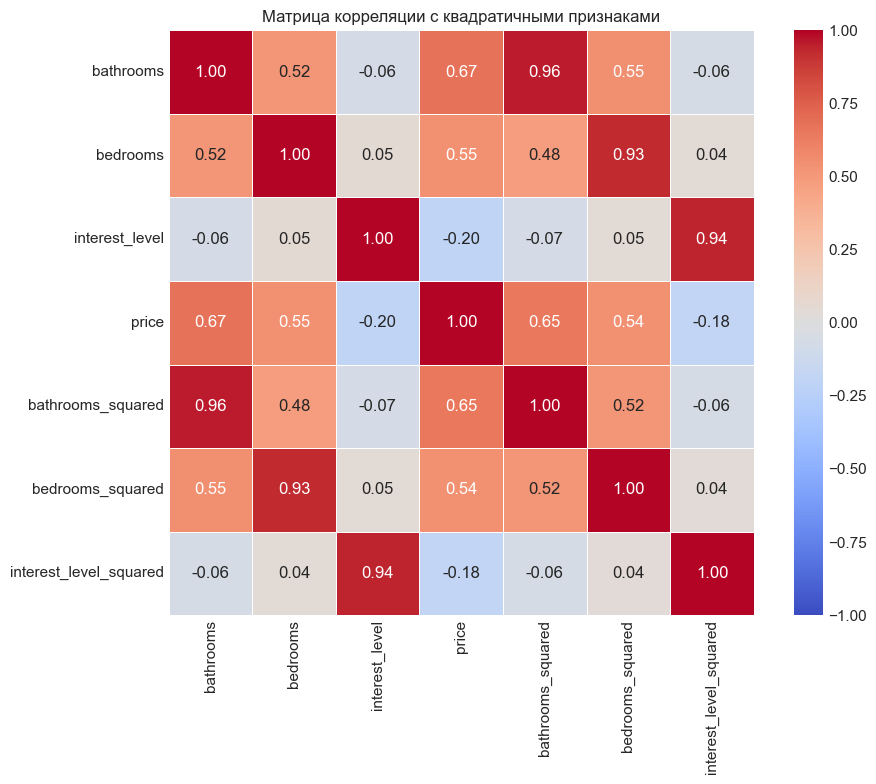

Корреляция с price:
price                     1.000000
bathrooms                 0.671943
bathrooms_squared         0.648486
bedrooms                  0.545948
bedrooms_squared          0.543406
interest_level_squared   -0.182672
interest_level           -0.200111
Name: price, dtype: float64


In [89]:
df_selected['bathrooms_squared'] = df_selected['bathrooms'] ** 2
df_selected['bedrooms_squared'] = df_selected['bedrooms'] ** 2
df_selected['interest_level_squared'] = df_selected['interest_level'] ** 2

# Матрица корреляции с новыми признаками
corr_matrix = df_selected.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Матрица корреляции с квадратичными признаками")
plt.tight_layout()
plt.show()

# Сравнение корреляции с price: исходные vs квадратичные
print("Корреляция с price:")
print(corr_matrix['price'].sort_values(ascending=False))

Что значит «квадратичный признак» и зачем он:

Линейная модель видит только прямую зависимость. Но связь может быть нелинейной: например, цена растёт не пропорционально числу спален, а ускоряется (3 спальни стоят больше, чем 3× цена одной). Признак bedrooms² даёт модели возможность уловить такой «изгиб». Это простейший приём feature engineering (создания признаков).

Квадратичные признаки коррелируют с ценой примерно так же или даже слабее исходных — заметного прироста корреляции нет. Это значит, что простое возведение в квадрат не добавило полезной линейной информации о цене. Само по себе создание признаков не гарантирует улучшения — признак должен реально отражать зависимость в данных.

In [90]:
model_features = ['bathrooms', 'bedrooms']
target = 'price'

df_selected = df_selected[model_features+[target]].copy()

In [91]:
# 4.4 Загрузка готовых train и test выборок
df_train = pd.read_json("data/train.json")
df_test = pd.read_json("data/test.json")

# Оставляем только нужные столбцы (модель использует bathrooms и bedrooms)
model_features = ['bathrooms', 'bedrooms']
target = 'price'

# Удаление выбросов по 1-му и 99-му процентилям из трейн и тест выборки
lower = df_train['price'].quantile(0.01)
upper = df_train['price'].quantile(0.99)

df_train = df_train[(df_train['price'] >= lower) & (df_train['price'] <= upper)].reset_index(drop=True)
df_test = df_test[(df_test['price'] >= lower) & (df_test['price'] <= upper)].reset_index(drop=True)



X_train = df_train[model_features].copy()
y_train = df_train[target].copy()

X_test = df_test[model_features].copy()
y_test = df_test[target].copy()

print("\nX_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)
X_train.head()


X_train: (48379, 2) | y_train: (48379,)
X_test:  (73255, 2) | y_test:  (73255,)


,bathrooms,bedrooms
0,1.0,1
1,1.0,2
2,1.0,2
3,1.5,3
4,1.0,0


In [92]:
# 4.5 Инициализация PolynomialFeatures со степенью 10
poly = PolynomialFeatures(degree=10)

PolynomialFeatures - это инструмент из sklearn, который создаёт новые признаки — степени и произведения исходных. Из bathrooms и bedrooms он сгенерирует все их комбинации до степени 10:

bathrooms, bedrooms,
bathrooms², bathrooms·bedrooms, bedrooms²,
bathrooms³, bathrooms²·bedrooms, ... и так до степени 10
То есть из 2 признаков получится много десятков новых (для degree=10 из 2 признаков — 66 столбцов).

Степень 10 — намеренно завышена. Задание специально просит её, чтобы увидеть переобучение (overfitting):

Модель с 66 признаками идеально подгонится под train,но на test ошибка будет большой.
Это педагогический пример: «слишком сложная модель запоминает обучающие данные вместо того, чтобы обобщать». 

In [93]:
# 4.6 Применение PolynomialFeatures к train и test
X_train = df_train[model_features]
X_test = df_test[model_features]

X_train_poly = poly.fit_transform(X_train)   # обучаем на train + трансформируем
X_test_poly = poly.transform(X_test)         # только трансформируем по правилам train

print("X_train до:", X_train.shape, "→ после:", X_train_poly.shape)
print("X_test  до:", X_test.shape,  "→ после:", X_test_poly.shape)

X_train до: (48379, 2) → после: (48379, 66)
X_test  до: (73255, 2) → после: (73255, 66)


Если вызвать fit на test, инструмент «подстроится» под тестовые данные → снова утечка данных (data leakage), как с процентилями раньше. Правило железное:

fit — только на train. К test — только transform.

Это общий принцип для всех преобразований sklearn (PolynomialFeatures, StandardScaler, и т.д.).

In [94]:
poly.get_feature_names_out(model_features)

array(['1', 'bathrooms', 'bedrooms', 'bathrooms^2', 'bathrooms bedrooms',
       'bedrooms^2', 'bathrooms^3', 'bathrooms^2 bedrooms',
       'bathrooms bedrooms^2', 'bedrooms^3', 'bathrooms^4',
       'bathrooms^3 bedrooms', 'bathrooms^2 bedrooms^2',
       'bathrooms bedrooms^3', 'bedrooms^4', 'bathrooms^5',
       'bathrooms^4 bedrooms', 'bathrooms^3 bedrooms^2',
       'bathrooms^2 bedrooms^3', 'bathrooms bedrooms^4', 'bedrooms^5',
       'bathrooms^6', 'bathrooms^5 bedrooms', 'bathrooms^4 bedrooms^2',
       'bathrooms^3 bedrooms^3', 'bathrooms^2 bedrooms^4',
       'bathrooms bedrooms^5', 'bedrooms^6', 'bathrooms^7',
       'bathrooms^6 bedrooms', 'bathrooms^5 bedrooms^2',
       'bathrooms^4 bedrooms^3', 'bathrooms^3 bedrooms^4',
       'bathrooms^2 bedrooms^5', 'bathrooms bedrooms^6', 'bedrooms^7',
       'bathrooms^8', 'bathrooms^7 bedrooms', 'bathrooms^6 bedrooms^2',
       'bathrooms^5 bedrooms^3', 'bathrooms^4 bedrooms^4',
       'bathrooms^3 bedrooms^5', 'bathrooms^2 bedroo

Зачем это нужно
Линейная регрессия умеет только складывать признаки с весами:


price ≈ w1·bathrooms + w2·bedrooms + b   ← только прямые линии
Добавив bathrooms², bedrooms² и т.д., мы даём ей возможность строить кривые (нелинейные зависимости):


price ≈ w1·bathrooms + w2·bedrooms + w3·bathrooms² + ... + b

## 5. Обучение моделей

### 5.1 Таблицы результатов

In [95]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

print("result_MAE:")
print(result_MAE)
print("\nresult_RMSE:")
print(result_RMSE)

result_MAE:
Empty DataFrame
Columns: [model, train, test]
Index: []

result_RMSE:
Empty DataFrame
Columns: [model, train, test]
Index: []


### 5.2 Линейная регрессия

In [96]:
# целевые переменные
y_train = df_train['price']
y_test = df_test['price']

# 1) Инициализация модели без параметров
lr = LinearRegression()

# 2) Обучение модели на полиномиальных признаках + предсказания
lr.fit(X_train_poly, y_train)

df_train['lr_pred'] = lr.predict(X_train_poly)   # сохраняем как новый столбец
df_test['lr_pred'] = lr.predict(X_test_poly)

# 3) MAE на train и test
mae_train = mean_absolute_error(y_train, df_train['lr_pred'])
mae_test = mean_absolute_error(y_test, df_test['lr_pred'])

# 4) RMSE на train и test
rmse_train = root_mean_squared_error(y_train, df_train['lr_pred'])
rmse_test = root_mean_squared_error(y_test, df_test['lr_pred'])

# 5) Запись в таблицы результатов
result_MAE.loc[len(result_MAE)] = ['linear_regression', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['linear_regression', rmse_train, rmse_test]

print(f"MAE  → train: {mae_train:.2f} | test: {mae_test:.2f}")
print(f"RMSE → train: {rmse_train:.2f} | test: {rmse_test:.2f}")

MAE  → train: 756.04 | test: 14766586211477616.00
RMSE → train: 1077.57 | test: 3996674085687979008.00


Линейная регрессия на полиномиальных признаках 10-й степени показывает классическое переобучение: ошибка на train мала (MAE≈756), а на test чудовищно велика (~10¹⁶). Модель запомнила обучающие данные вместо выявления закономерности и полностью провалилась на новых данных. Вывод: чрезмерно сложная модель (высокая степень полинома) не обобщает. Это демонстрирует, почему сложность модели нужно контролировать.

### 5.3 Decision Tree

In [97]:
# 1) Инициализация с фиксированным random_state
dt = DecisionTreeRegressor(random_state=21)

# 2) Обучение + предсказания
dt.fit(X_train_poly, y_train)

df_train['dt_pred'] = dt.predict(X_train_poly)   # новый столбец с предсказаниями
df_test['dt_pred'] = dt.predict(X_test_poly)

# 3) MAE на train и test
mae_train = mean_absolute_error(y_train, df_train['dt_pred'])
mae_test = mean_absolute_error(y_test, df_test['dt_pred'])

# 4) RMSE на train и test
rmse_train = root_mean_squared_error(y_train, df_train['dt_pred'])
rmse_test = root_mean_squared_error(y_test, df_test['dt_pred'])

# 5) Запись в таблицы результатов
result_MAE.loc[len(result_MAE)] = ['decision_tree', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['decision_tree', rmse_train, rmse_test]

print(f"MAE  → train: {mae_train:.2f} | test: {mae_test:.2f}")
print(f"RMSE → train: {rmse_train:.2f} | test: {rmse_test:.2f}")

MAE  → train: 756.04 | test: 759.76
RMSE → train: 1077.48 | test: 1081.75


Дерево решений (random_state=21) показало MAE≈756 на train и ≈760 на test — практически одинаково. Переобучения нет: из-за малого числа уникальных комбинаций bathrooms/bedrooms дерево не может запомнить отдельные квартиры и предсказывает среднюю цену по группе признаков. Эта группировка хорошо обобщается на test. По сравнению с полиномиальной линейной регрессией (test-ошибка ~10¹⁶) дерево несопоставимо надёжнее.

### 5.4 Наивные модели (Naive)

In [98]:
# Константы считаем НА TRAIN (как в реальности — test нам "неизвестен")
mean_price = y_train.mean()
median_price = y_train.median()

print(f"Среднее (train): {mean_price:.2f}")
print(f"Медиана (train): {median_price:.2f}")

# Столбцы с предсказаниями (одно и то же значение для всех строк)
df_train['naive_mean_pred'] = mean_price
df_test['naive_mean_pred'] = mean_price
df_train['naive_median_pred'] = median_price
df_test['naive_median_pred'] = median_price

# --- naive_mean: метрики ---
mae_train = mean_absolute_error(y_train, df_train['naive_mean_pred'])
mae_test = mean_absolute_error(y_test, df_test['naive_mean_pred'])
rmse_train = root_mean_squared_error(y_train, df_train['naive_mean_pred'])
rmse_test = root_mean_squared_error(y_test, df_test['naive_mean_pred'])

result_MAE.loc[len(result_MAE)] = ['naive_mean', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['naive_mean', rmse_train, rmse_test]

print(f"\nnaive_mean   MAE → train: {mae_train:.2f} | test: {mae_test:.2f}")
print(f"naive_mean   RMSE → train: {rmse_train:.2f} | test: {rmse_test:.2f}")

# --- naive_median: метрики ---
mae_train = mean_absolute_error(y_train, df_train['naive_median_pred'])
mae_test = mean_absolute_error(y_test, df_test['naive_median_pred'])
rmse_train = root_mean_squared_error(y_train, df_train['naive_median_pred'])
rmse_test = root_mean_squared_error(y_test, df_test['naive_median_pred'])

result_MAE.loc[len(result_MAE)] = ['naive_median', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['naive_median', rmse_train, rmse_test]

print(f"naive_median MAE → train: {mae_train:.2f} | test: {mae_test:.2f}")
print(f"naive_median RMSE → train: {rmse_train:.2f} | test: {rmse_test:.2f}")

Среднее (train): 3538.64
Медиана (train): 3150.00

naive_mean   MAE → train: 1139.19 | test: 1137.83
naive_mean   RMSE → train: 1597.65 | test: 1590.39
naive_median MAE → train: 1086.21 | test: 1084.59
naive_median RMSE → train: 1644.24 | test: 1635.40


Наивная модель — это «модель без модели»: она не смотрит на признаки вообще, а тупо выдаёт одно число для всех:

naive_mean — всегда предсказывает среднюю цену,
naive_median — всегда предсказывает медианную цену.
Зачем нужна: это точка отсчёта (baseline). Любая «настоящая» модель (LR, дерево) обязана работать лучше наивной — иначе она бесполезна. Если линейная регрессия проигрывает «среднему», значит она ничему не научилась.


naive_median даёт меньший MAE (1085 против 1138), naive_mean — меньший RMSE (1590 против 1635). Это согласуется с теорией: MAE минимизируется медианой, RMSE — средним. Скошенность цены вправо делает медиану более репрезентативной. Обе наивные модели уступают дереву решений (MAE 760), но превосходят переобученную полиномиальную регрессию — простой baseline оказался надёжнее чрезмерно сложной модели.

Константа, которая минимизирует MAE, — это всегда медиана.

Константа, которая минимизирует RMSE (среднеквадратичную ошибку), — это всегда среднее.

### 5.5 Сравнение результатов

In [99]:
print("=" * 50)
print("Таблица MAE (средняя абсолютная ошибка):")
display(result_MAE)

print("=" * 50)
print("Таблица RMSE (корень среднеквадратичной ошибки):")
display(result_RMSE)

# Лучшая модель по test (исключаем взорвавшуюся линейную регрессию для наглядности)
print("=" * 50)
best_mae = result_MAE.loc[result_MAE['test'].idxmin()]
best_rmse = result_RMSE.loc[result_RMSE['test'].idxmin()]
print(f"Лучшая модель по MAE (test):  {best_mae['model']} → {best_mae['test']:.2f}")
print(f"Лучшая модель по RMSE (test): {best_rmse['model']} → {best_rmse['test']:.2f}")


Таблица MAE (средняя абсолютная ошибка):


,model,train,test
0,linear_regression,756.040300,1.476659e+16
1,decision_tree,756.044735,7.597629e+02
2,naive_mean,1139.192515,1.137832e+03
3,naive_median,1086.210505,1.084588e+03


Таблица RMSE (корень среднеквадратичной ошибки):


,model,train,test
0,linear_regression,1077.566356,3.996674e+18
1,decision_tree,1077.483596,1.081755e+03
2,naive_mean,1597.646655,1.590391e+03
3,naive_median,1644.236439,1.635396e+03


Лучшая модель по MAE (test):  decision_tree → 759.76
Лучшая модель по RMSE (test): decision_tree → 1081.75
